# Домашнє завдання до модуля «Вступ до NLP»
## Завантажуємо датасет

In [163]:
from pathlib import Path

import kagglehub

# Download latest version
path = Path(kagglehub.dataset_download("shantanudhakadd/email-spam-detection-dataset_obj-classification")) / "spam.csv"

print("Path to dataset_obj files:", path)

Path to dataset files: /Users/kozak_mamay/.cache/kagglehub/datasets/shantanudhakadd/email-spam-detection-dataset-classification/versions/1/spam.csv


## Визначаємо необхідні функції та класи
### Функція перетворення датасету у датафрейм

In [164]:
import pandas as pd

def convert_to_pandas_df(data_path: Path | str) -> pd.DataFrame:
    """
    Robust CSV loader for the common Kaggle 'spam.csv' style datasets.

    Tries multiple encodings (utf-8/utf-8-sig/cp1252/latin-1), then falls back
    to 'replace' to avoid runtime crashes while keeping data usable.
    """
    data_path = Path(data_path)

    encodings_to_try = ("utf-8", "utf-8-sig", "cp1252", "latin-1")

    for enc in encodings_to_try:
        try:
            raw = pd.read_csv(
                data_path,
                encoding=enc,
                engine="python",
            )
            break
        except UnicodeDecodeError as e:
            print(f"Помилка декодування CSV: {e}")
    else:
        # Final fallback: don't crash, but mark undecodable bytes.
        raw = pd.read_csv(
            data_path,
            encoding="utf-8",
            encoding_errors="replace",
            engine="python",
        )

    if raw.shape[1] < 2:
        raise ValueError(
            f"Очікував щонайменше 2 колонки (label, text), але отримав {raw.shape[1]}."
        )

    df = raw.iloc[:, :2].copy()
    df.columns = ["label", "text"]

    # Normalize types
    df["label"] = df["label"].astype(str).str.strip()
    df["text"] = df["text"].astype(str)

    return df

### Функція візуалізації розподілу класів

In [165]:
from matplotlib import pyplot as plt


def show_dest_var_destination(df: pd.DataFrame, dest_var: str="label"):
    # Кількість прикладів у кожному класі
    counts = df[dest_var].value_counts()

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    # 1) Барчарт за кількістю
    counts.plot(kind="bar", ax=axes[0], color=["#4C78A8", "#F58518"])
    axes[0].set_title("Розподіл label (кількість)")
    axes[0].set_xlabel(dest_var)
    axes[0].set_ylabel("кількість")
    axes[0].tick_params(axis="x", rotation=0)

    # 2) Барчарт за відсотками
    (counts / counts.sum() * 100).plot(kind="bar", ax=axes[1], color=["#4C78A8", "#F58518"])
    axes[1].set_title("Розподіл label (%)")
    axes[1].set_xlabel("label")
    axes[1].set_ylabel("%")
    axes[1].tick_params(axis="x", rotation=0)

    plt.tight_layout()
    plt.show()

### Словник розгортання скорочень

In [166]:
# Словник розгортання англійських скорочень (contractions): "don't" -> "do not", тощо
contractions = {
    "ain't": "am not",
    "aren't": "are not",
    "can't": "cannot",
    "can't've": "cannot have",
    "'cause": "because",
    "could've": "could have",
    "couldn't": "could not",
    "couldn't've": "could not have",
    "didn't": "did not",
    "doesn't": "does not",
    "don't": "do not",
    "hadn't": "had not",
    "hadn't've": "had not have",
    "hasn't": "has not",
    "haven't": "have not",
    "he'd": "he would",
    "he'd've": "he would have",
    "he'll": "he will",
    "he's": "he is",
    "how'd": "how did",
    "how'll": "how will",
    "how's": "how is",
    "i'd": "i would",
    "i'll": "i will",
    "i'm": "i am",
    "i've": "i have",
    "isn't": "is not",
    "it'd": "it would",
    "it'll": "it will",
    "it's": "it is",
    "let's": "let us",
    "ma'am": "madam",
    "mayn't": "may not",
    "might've": "might have",
    "mightn't": "might not",
    "must've": "must have",
    "mustn't": "must not",
    "needn't": "need not",
    "oughtn't": "ought not",
    "shan't": "shall not",
    "sha'n't": "shall not",
    "she'd": "she would",
    "she'll": "she will",
    "she's": "she is",
    "should've": "should have",
    "shouldn't": "should not",
    "that'd": "that would",
    "that's": "that is",
    "there'd": "there had",
    "there's": "there is",
    "they'd": "they would",
    "they'll": "they will",
    "they're": "they are",
    "they've": "they have",
    "wasn't": "was not",
    "we'd": "we would",
    "we'll": "we will",
    "we're": "we are",
    "we've": "we have",
    "weren't": "were not",
    "what'll": "what will",
    "what're": "what are",
    "what's": "what is",
    "what've": "what have",
    "where'd": "where did",
    "where's": "where is",
    "who'll": "who will",
    "who's": "who is",
    "won't": "will not",
    "wouldn't": "would not",
    "you'd": "you would",
    "you'll": "you will",
    "you're": "you are"
}


### Список заперечень

In [167]:
# Набір заперечень: їх НЕ прибираємо зі стоп-слів, щоб не втрачати зміст ("not good" ≠ "good")
negations = {
    'aren',
    "aren't",
    'couldn',
    "couldn't",
    'didn',
    "didn't",
    'doesn',
    "doesn't",
    'don',
    "don't",
    'hadn',
    "hadn't",
    'hasn',
    "hasn't",
    'haven',
    "haven't",
    'isn',
    "isn't",
    'mightn',
    "mightn't",
    'mustn',
    "mustn't",
    'needn',
    "needn't",
    'no',
    'nor',
    'not',
    'shan',
    "shan't",
    'shouldn',
    "shouldn't",
    'wasn',
    "wasn't",
    'weren',
    "weren't",
    'won',
    "won't",
    'wouldn',
    "wouldn't"
}


### Перерахунок регулярних виразів, якими очищаємо вхідний текст

In [168]:
# Регулярні вирази для типових підчищень у тексті (HTML/URL/email/не-літери тощо)
from enum import Enum

class TextSubtractions(Enum):
    HTML_TAGS = r"<[^>]*>"
    URLS = r"http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\(\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+"
    EMAILS = r"[^@ \t\r\n]+@[^@ \t\r\n]+"
    NON_WHITE_SPACES = r"\\S*@\\S*[\\s]+"
    NON_LETTERS = r"[^a-zA-Z'\s]+"


### Клас для підготовки текстів: очищення, видалення стоп-слів, лематизація/стемінг

In [169]:
# Клас для підготовки текстів: очищення, видалення стоп-слів, лематизація/стемінг
import re

import spacy
from nltk.stem import PorterStemmer
from nltk.corpus import stopwords


class WordCorpus:
    EXTRA_STOP_WORDS = {"also", "would", "much", "many"}

    def __init__(self, df: pd.DataFrame, *, nlp=None, text_column: str = "text"):
        self._df = df.copy()
        self._text_column = text_column

        base_stop_words = set(stopwords.words("english"))
        self._stop_words = (base_stop_words | self.EXTRA_STOP_WORDS) - set(negations)

        # Завжди тримаємо текст як Series (1 елемент = 1 документ)
        self._text = self._df[self._text_column].astype(str).str.lower()

        # spaCy pipeline можна передати ззовні (краще для продуктивності/тестів)
        self._nlp = nlp

    def __enter__(self):
        for step in self._preprocess_pipeline():
            step()
        return self

    def __exit__(self, exc_type, exc_val, exc_tb):
        return False

    def __call__(self) -> pd.DataFrame:
        self._df[self._text_column] = self._text
        return self._df

    def _preprocess_pipeline(self):
        return (
            self.remove_urls,
            self.remove_emails,
            self.remove_non_letters,
            self.remove_contractions,
            self.remove_stop_words,
            self.lemmatize_words
        )

    def _replace_pattern(self, pattern: TextSubtractions) -> None:
        self._text = self._text.str.replace(pattern.value, "", regex=True)

    def remove_html_tags(self) -> None:
        self._replace_pattern(TextSubtractions.HTML_TAGS)

    def remove_urls(self) -> None:
        self._replace_pattern(TextSubtractions.URLS)

    def remove_emails(self) -> None:
        self._replace_pattern(TextSubtractions.EMAILS)

    def remove_non_white_spaces(self) -> None:
        self._replace_pattern(TextSubtractions.NON_WHITE_SPACES)

    def remove_non_letters(self) -> None:
        self._replace_pattern(TextSubtractions.NON_LETTERS)

    def remove_contractions(self) -> None:
        # Розгортаємо скорочення на рівні кожного документа, працюємо зі словами
        def expand(doc: str) -> str:
            tokens = doc.split()
            expanded = [contractions.get(tok, tok) for tok in tokens]
            return " ".join(expanded)

        self._text = self._text.apply(expand)

    def remove_stop_words(self) -> None:
        def drop_stop_words(doc: str) -> str:
            tokens = doc.split()
            filtered = [tok for tok in tokens if tok not in self._stop_words]
            return " ".join(filtered)

        self._text = self._text.apply(drop_stop_words)

    def _get_nlp(self):
        if self._nlp is None:
            self._nlp = spacy.load("en_core_web_sm", disable = ['parser','ner'])
        return self._nlp

    def lemmatize_words(self) -> None:
        """
        Нормалізація тексту.
        - Якщо доступна spaCy-модель: лематизація через spaCy.
        - Якщо ні: запасний варіант (fallback) — PorterStemmer (стабільно, без додаткових ресурсів).
        """
        nlp = self._get_nlp()
        stemmer = PorterStemmer()

        def normalize(doc: str) -> str:
            if not isinstance(doc, str) or not doc.strip():
                return ""

            if nlp is not None:
                spacy_doc = nlp(doc)
                return " ".join(
                    t.lemma_.lower()
                    for t in spacy_doc
                    if not t.is_space
                )

            # fallback
            tokens = re.findall(r"[A-Za-z]+(?:'[A-Za-z]+)?", doc.lower())
            return " ".join(stemmer.stem(tok) for tok in tokens)

        self._df["text"] = self._df["text"].astype(str).map(normalize)

    def build_corpus(self):
        self._df["tokens"] = self._df["text"].str.split()


### Базовий клас для отримання векторного представлення тексту (ембедінги)

In [170]:
# Абстрактний базовий клас для отримання векторного представлення тексту (ембедінги)
from abc import ABC, abstractmethod

import numpy as np
import pandas as pd


class WordEmbedding(ABC):
    """
    Базовий клас-трансформер: Series[str] -> ndarray (n_samples, vector_size)
    УВАГА: тут НЕ викликаємо model.fit(), бо різні бекенди (KeyedVectors, TF-IDF, тощо)
    мають різні API. fit() лише гарантує, що self.model ініціалізований.
    """

    def __init__(self, *, vector_size: int, lowercase: bool = True):
        self.vector_size = int(vector_size)
        self.lowercase = lowercase
        self.model = None

    @abstractmethod
    def init_model(self):
        """Має повернути "модель/ресурс", який потрібен для vectorize_document()."""
        raise NotImplementedError

    def vectorize_document(self, text: str) -> np.ndarray:
        """Повертає вектор розмірності (vector_size,) для одного документа."""
        tokens = text.split()
        vecs = [self.model[t] for t in tokens if t in self.model]

        if not vecs:
            return np.zeros((self.vector_size,), dtype=np.float32)

        return np.mean(vecs, axis=0).astype(np.float32)

    def fit(self, X: pd.Series, y=None):
        # Ліниво ініціалізуємо модель один раз.
        if self.model is None:
            self.model = self.init_model()
            if self.model is None:
                raise ValueError("init_model() повернув None. Поверніть модель явно через return.")
        return self

    def transform(self, X: pd.Series) -> np.ndarray:
        if self.model is None:
            # sklearn зазвичай робить fit() перед transform(), але краще мати явну помилку
            raise ValueError("Трансформер не fitted: викличте fit() перед transform().")

        texts = list(X)
        out = np.zeros((len(texts), self.vector_size), dtype=np.float32)

        for i, text in enumerate(texts):
            s = "" if text is None else str(text)
            if self.lowercase:
                s = s.lower()
            out[i] = self.vectorize_document(s)

        return out

    def fit_transform(self, X: pd.Series, y=None) -> np.ndarray:
        return self.fit(X, y).transform(X)


### Попередньо навчені ембедінги Word2Vec (GoogleNews 300d), завантаження через kagglehub

In [171]:
# Попередньо навчені ембедінги Word2Vec (GoogleNews 300d), завантаження через kagglehub
import kagglehub

class WordToVecPretrained(WordEmbedding):
    def __init__(self, *, lowercase: bool = True):
        # GoogleNews — 300-вимірні вектори
        super().__init__(vector_size=300, lowercase=lowercase)

    def init_model(self):
        datapath = (
            Path(kagglehub.dataset_download("leadbest/googlenewsvectorsnegative300"))
            / "GoogleNews-vectors-negative300.bin"
        )
        kv = gensim.models.KeyedVectors.load_word2vec_format(str(datapath), binary=True)

        # Узгоджуємо vector_size з реальним розміром моделі (про всяк випадок)
        self.vector_size = int(getattr(kv, "vector_size", self.vector_size))
        return kv


### Попередньо навчені ембедінги GloVe (завантаження zip, розпаковка, читання в KeyedVectors)

In [172]:
# Попередньо навчені ембедінги GloVe (завантаження zip, розпаковка, читання в KeyedVectors)
import zipfile
import requests
import tempfile
import weakref
from pathlib import Path

import gensim


class GloVeVecPretrained(WordEmbedding):
    def __init__(self, *, lowercase: bool = True):
        super().__init__(vector_size=300, lowercase=lowercase)

        self.tmp_dir = Path(tempfile.gettempdir()) / "glove_tmp"
        self.tmp_dir.mkdir(parents=True, exist_ok=True)

        self.fn_path: Path | None = None
        self.zip_path: Path | None = None
        self._finalizer = None

    @staticmethod
    def _safe_unlink(p):
        try:
            if p is None:
                return
            p = Path(p)
            if p.exists():
                p.unlink()
        except Exception:
            pass

    @classmethod
    def _cleanup_files(cls, fn_path, zip_path):
        cls._safe_unlink(fn_path)
        cls._safe_unlink(zip_path)

    def cleanup(self):
        """Явне прибирання файлів (за бажанням)."""
        self._cleanup_files(self.fn_path, self.zip_path)

    def init_model(self):
        URL = "https://nlp.stanford.edu/data/wordvecs/glove.2024.dolma.300d.zip"
        self.zip_path = self.tmp_dir / "glove.2024.dolma.300d.zip"

        # 1) Завантаження (якщо файлу немає або він порожній)
        if (not self.zip_path.exists()) or self.zip_path.stat().st_size == 0:
            print(f"Завантажую {URL} ...")
            with requests.get(URL, stream=True, timeout=180) as r:
                r.raise_for_status()
                with open(self.zip_path, "wb") as f:
                    for chunk in r.iter_content(chunk_size=1024 * 1024):
                        if chunk:
                            f.write(chunk)

        # 2) Перевірка zip
        if not zipfile.is_zipfile(self.zip_path):
            raise ValueError(
                f"Файл {self.zip_path} не є валідним zip-архівом (можливо, недокачаний). "
                f"Видаліть його і запустіть ще раз."
            )

        # 3) Розпаковка
        print("Розпаковую GloVe архів...")
        with zipfile.ZipFile(self.zip_path, "r") as zf:
            zf.extractall(self.tmp_dir)

        # 4) Пошук txt з векторами (беремо найбільший)
        txt_candidates = list(self.tmp_dir.rglob("*.txt"))
        if not txt_candidates:
            raise ValueError(
                f"Після розпаковки {self.zip_path.name} не знайдено жодного .txt файлу з векторами."
            )

        txt_candidates.sort(key=lambda p: p.stat().st_size, reverse=True)
        self.fn_path = txt_candidates[0]

        # 5) Фіналізатор на випадок збору сміття (не обов’язково, але ок)
        if self._finalizer is None:
            self._finalizer = weakref.finalize(self, self._cleanup_files, self.fn_path, self.zip_path)

        # 6) Мінімальна валідація формату
        with self.fn_path.open("r", encoding="utf-8", errors="ignore") as f:
            first_line = f.readline().strip()
        parts = first_line.split()
        if len(parts) < 3:
            raise ValueError(f"Підозрілий формат у {self.fn_path.name}: перший рядок {first_line!r}")
        try:
            float(parts[1])
            float(parts[2])
        except ValueError as e:
            raise ValueError(
                f"{self.fn_path.name} не схожий на GloVe: перший рядок {first_line!r}"
            ) from e

        # 7) Завантаження KeyedVectors
        print(f"Завантажую GloVe-вектори з: {self.fn_path}")
        kv = gensim.models.KeyedVectors.load_word2vec_format(
            str(self.fn_path),
            binary=False,
            no_header=True,
            encoding="utf8",
            unicode_errors="ignore",
        )

        self.vector_size = int(getattr(kv, "vector_size", self.vector_size))
        return kv

    def __del__(self):
        try:
            self.cleanup()
        except Exception:
            pass

### Перетворення датасету в датафрейм

In [173]:
df = convert_to_pandas_df(path)

df.head()

Помилка декодування CSV: 'utf-8' codec can't decode bytes in position 606-607: invalid continuation byte
Помилка декодування CSV: 'utf-8' codec can't decode bytes in position 606-607: invalid continuation byte


,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


### Показуємо розподіл класів у цільовій змінній

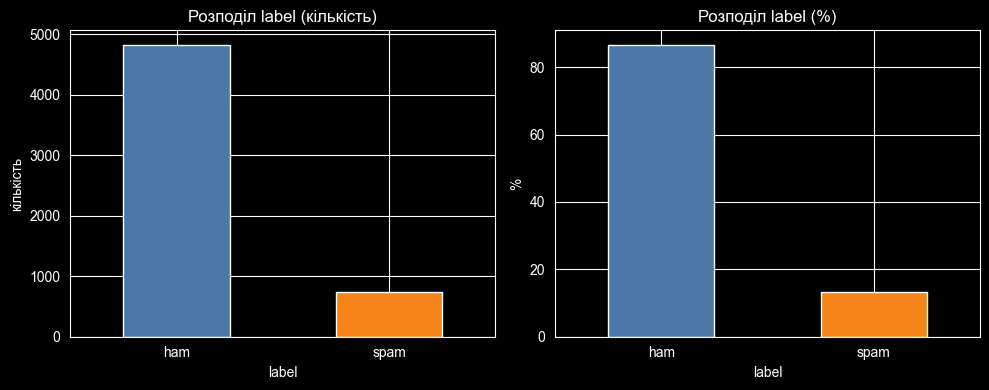

In [174]:
show_dest_var_destination(df)

### Робимо попередню обробку тексту у датасеті та підготовка даних

In [175]:
with WordCorpus(df) as corpus:
    df = corpus()

df.head()

,label,text
0,ham,go jurong point crazy available bugis n great ...
1,ham,ok lar joking wif u oni
2,spam,free entry wkly comp win fa cup final tkts st ...
3,ham,u dun say early hor u c already say
4,ham,nah not think goes usf lives around though


### Підготовка даних для моделі

In [176]:
from sklearn.preprocessing import LabelEncoder

X = df["text"]
y = df["label"]

y = LabelEncoder().fit_transform(y)

### Розділяємо дані на тренувальний та валідаційний набори

In [177]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### Конвеєр для TF-IDF векторизації

In [178]:
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline

tfidf_vectorizer_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=10000,
        ngram_range=(1, 2),
        stop_words="english"
    )),
    ("clf", LogisticRegression(max_iter=1000))
])

### Тренуємо конвеєр для TF-IDF векторизації

In [179]:
tfidf_vectorizer_pipeline.fit(X_train, y_train)

,steps,"[('tfidf', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


### Конвеєр для CountVectorizer векторизації

In [180]:
from sklearn.feature_extraction.text import CountVectorizer

count_vectorizer_pipeline = Pipeline([
    ("cvec", CountVectorizer(
    max_features=5000,
    stop_words="english"
    )),
    ("clf", LogisticRegression(max_iter=1000))
])

### Тренування моделі на основі CountVectorizer векторизації

In [181]:
count_vectorizer_pipeline.fit(X_train, y_train)

,steps,"[('cvec', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


### Конвеєри для Word2Vec та GloVe векторизації

In [182]:
glov_vec_pipeline = word2vec_pipeline = Pipeline([
    ("word2vec", GloVeVecPretrained()),
    ("clf", LogisticRegression(max_iter=1000))
])

In [183]:
word2vec_pipeline = Pipeline([
    ("word2vec", WordToVecPretrained()),
    ("clf", LogisticRegression(max_iter=1000))
])

### Тренування напередтренованих векторів моделей

In [184]:
word2vec_pipeline.fit(X_train, y_train)

,steps,"[('word2vec', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None


In [185]:
glov_vec_pipeline.fit(X_train, y_train)

Розпаковую GloVe архів...
Завантажую GloVe-вектори з: /var/folders/9f/3qm3m8k90w108hgmspdbjnph0000gp/T/glove_tmp/dolma_300_2024_1.2M.100_combined.txt


,steps,"[('word2vec', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None


### Оцінюємо якість моделей
#### Оцінка моделі на основі TF-IDF векторизації

In [186]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score

y_pred_tfidf = tfidf_vectorizer_pipeline.predict(X_val)
acc = accuracy_score(y_val, y_pred_tfidf)
auc = roc_auc_score(y_val, y_pred_tfidf)

print(f"Accuracy Score: {acc:.3f}, AUC: {auc:.3f}")

Accuracy Score: 0.961, AUC: 0.859


#### Оцінка моделі на основі CountVectorizer векторизації

In [187]:
y_pred_count_vectorizer = count_vectorizer_pipeline.predict(X_val)
acc1 = accuracy_score(y_val, y_pred_count_vectorizer)
auc1 = roc_auc_score(y_val, y_pred_tfidf)

print(f"Accuracy Score: {acc1:.3f}, AUC: {auc1:.3f}")

Accuracy Score: 0.976, AUC: 0.859


#### Оцінка моделі на основі Word2Vec векторизації

In [188]:
y_pred_word2vec = word2vec_pipeline.predict(X_val)
acc2 = accuracy_score(y_val, y_pred_word2vec)
auc2 = roc_auc_score(y_val, y_pred_word2vec)

print(f"Accuracy Score: {acc2:.3f}, AUC: {auc2:.3f}")

Accuracy Score: 0.946, AUC: 0.867


#### Оцінка моделі на основі GloVe векторизації

In [189]:
y_pred3 = glov_vec_pipeline.predict(X_val)
acc3 = accuracy_score(y_val, y_pred3)
auc3 = roc_auc_score(y_val, y_pred3)

print(f"Accuracy Score: {acc3:.3f}, AUC: {auc3:.3f}")

Accuracy Score: 0.955, AUC: 0.886


#### Зведена порівняльна оцінка якості різних моделей

| Ранг | Модель (векторизація + класифікатор) | Accuracy | AUC   |
|-----:|---|---:|---:|
|    1 | CountVectorizer (5k) + Logistic Regression | 0.976 | 0.859 |
|    2 | TF-IDF (1–2 грами, 10k) + Logistic Regression | 0.961 | 0.859 |
|    3 | GloVe (Dolma 300d) + Logistic Regression | 0.955 | 0.886 |
|    4 | Word2Vec (GoogleNews 300d) + Logistic Regression | 0.946 | 0.867 |


## Висновки

Ми провели порівняння трьох моделей з використанням різних методів векторизації тексту: TF-IDF, CountVectorizer та Word2Vec/GloVe.

Модель CountVectorizer (5k) + Logistic Regression показала найкращі результати з точністю 0.976 та AUC 0.859. TF-IDF (1–2 грами, 10k) + Logistic Regression наступила за ним з точністю 0.961 та AUC 0.859. GloVe (Dolma 300d) + Logistic Regression показала наступні результати з точністю 0.955 та AUC 0.886. Word2Vec (GoogleNews 300d).

Отже, ефективнішими виявилися з нуля натреновані моделі на основі бібліотек з модуля **sklearn**. Вони демонструють високу точність та високий AUC, що я можу пояснити тим, що вони не вимагають додаткової тренувальної фази, а також що вони тренуються на базі самого датасету, тоді як попередньо навчені — уже мають готову базу, не конче повʼязану із самим датасетом.
Що це означає? Хоч метрики акуратності вказують на натреновані з нуля моделі перед попередньо натренованими, тим не менш такі високі бали можуть бути повʼязаними з перенавчанням. Тоді, коли попередньо натреновані моделі показують високі результати без такої небезпеки.